# G-H Filter

In [ ]:
"""
    TITLE   : Basic G-H Filter for Track
    PROJECT : trackstream
""";

__author__ = 'Nathaniel Starkman'

<span style='font-size:30px;font-weight:650'>
    About
</span>



<br><br>

- - - 


## Prepare

### Imports

In [2]:
from utilipy import ipython

ipython.set_autoreload(2)
ipython.run_imports(base=True, astropy=True, matplotlib=True)


# BUILT-IN

# THIRD PARTY

from filterpy.gh import GHFilter, GHKFilter


# PROJECT-SPECIFIC

from trackstream import examples
from trackstream import preprocessing as prep
from trackstream.utils import convert


set autoreload to 1
set autoreload to 2


### Orbit Data

In [3]:
orb_ord = examples.make_ordered_orbit_data()
orb_obs = examples.make_noisy_orbit_data()

orb_clr = np.linspace(0, 256, len(orb_ord))

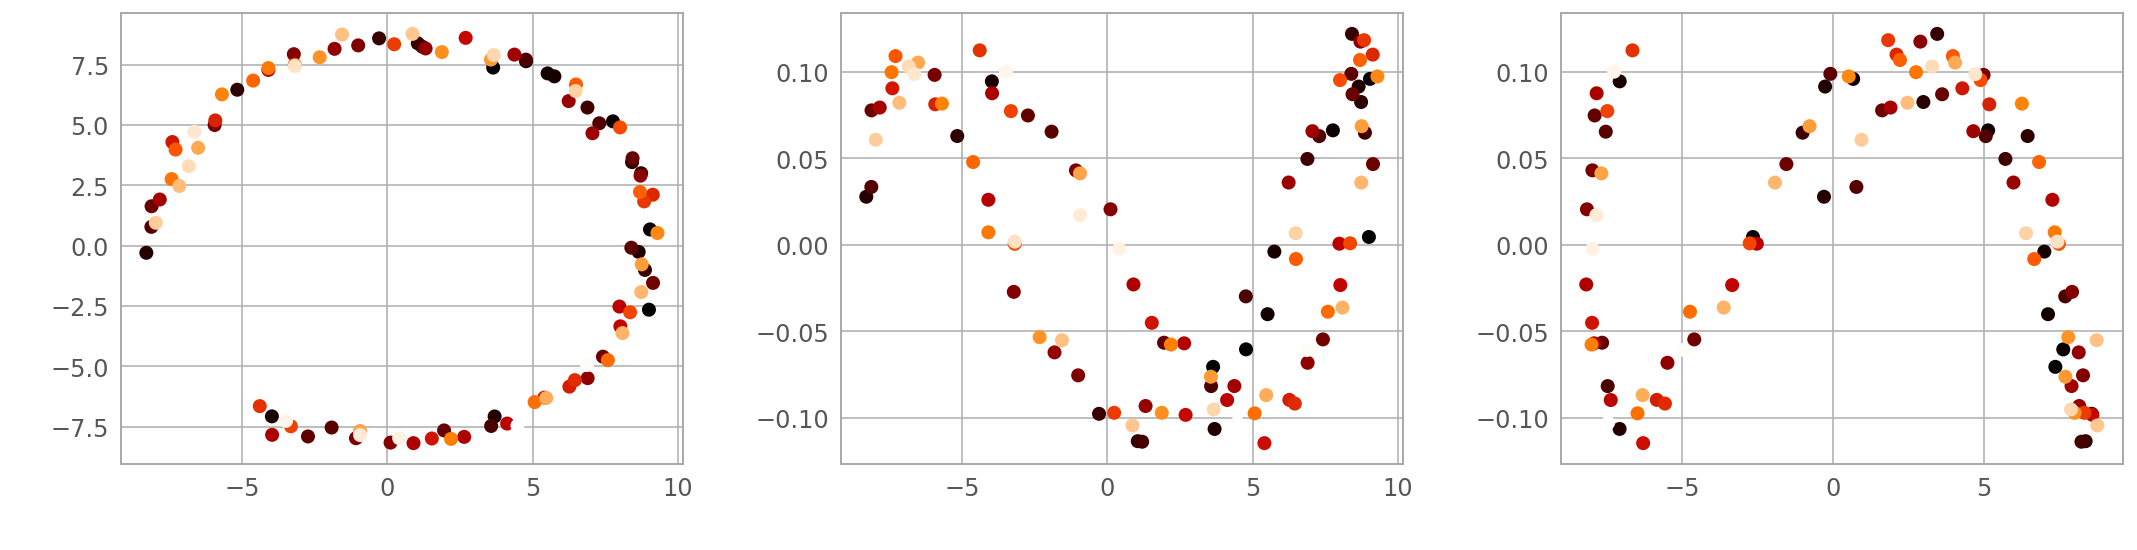

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(orb_obs.x, orb_obs.y, c=orb_clr)
axs[1].scatter(orb_obs.x, orb_obs.z, c=orb_clr)
axs[2].scatter(orb_obs.y, orb_obs.z, c=orb_clr)
plt.tight_layout()
plt.show();

### NBody Data

In [5]:
nbd_obs = examples.get_nbody()

nbd_clr = np.linspace(0, 256, len(nbd_obs))

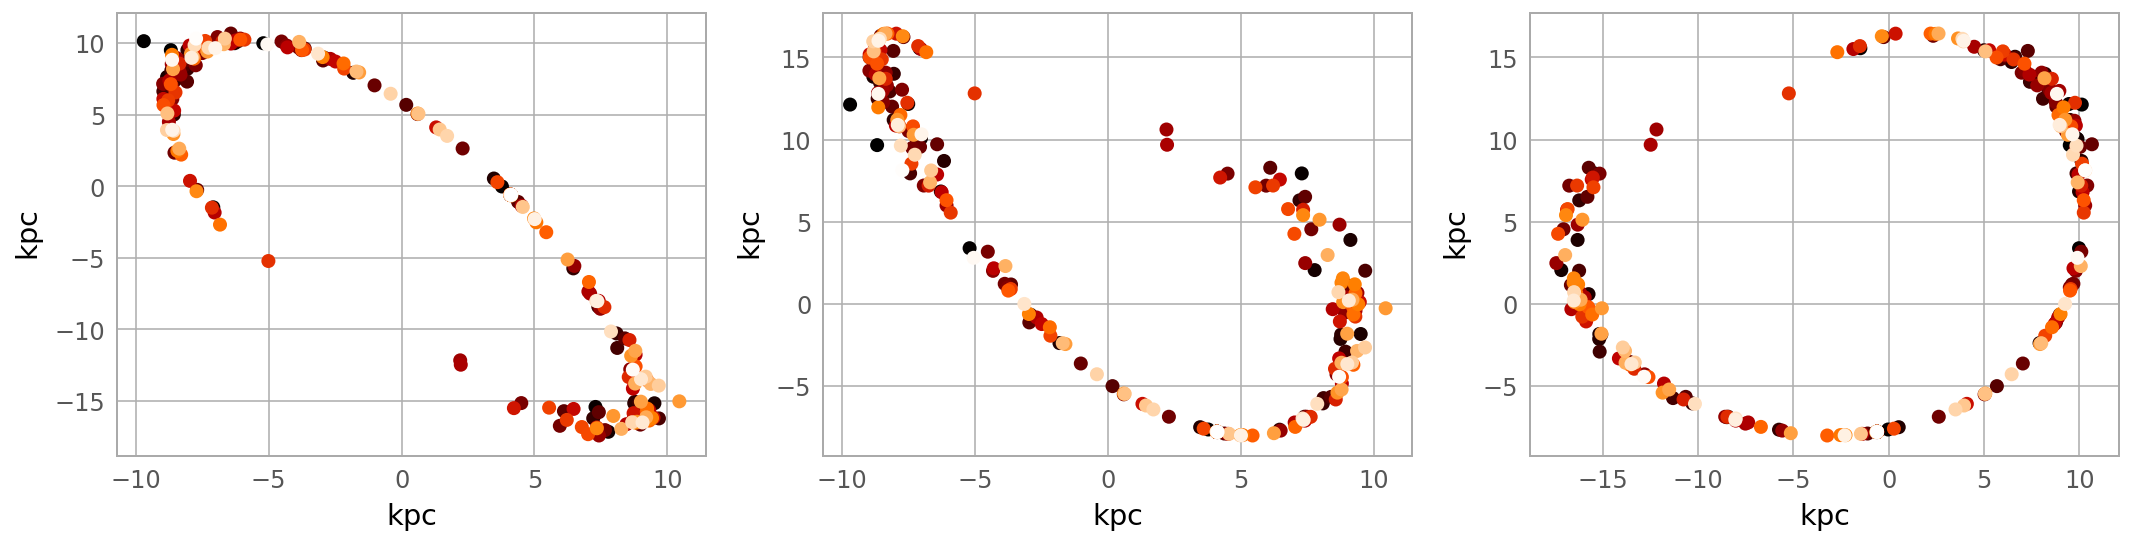

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(nbd_obs.x, nbd_obs.y, c=nbd_clr)
axs[1].scatter(nbd_obs.x, nbd_obs.z, c=nbd_clr)
axs[2].scatter(nbd_obs.y, nbd_obs.z, c=nbd_clr)
plt.tight_layout()
plt.show();

### Obs Data

In [7]:
pal5_obs = examples.get_stream_data().cartesian

pal5_clr = np.linspace(0, 256, len(pal5_obs))

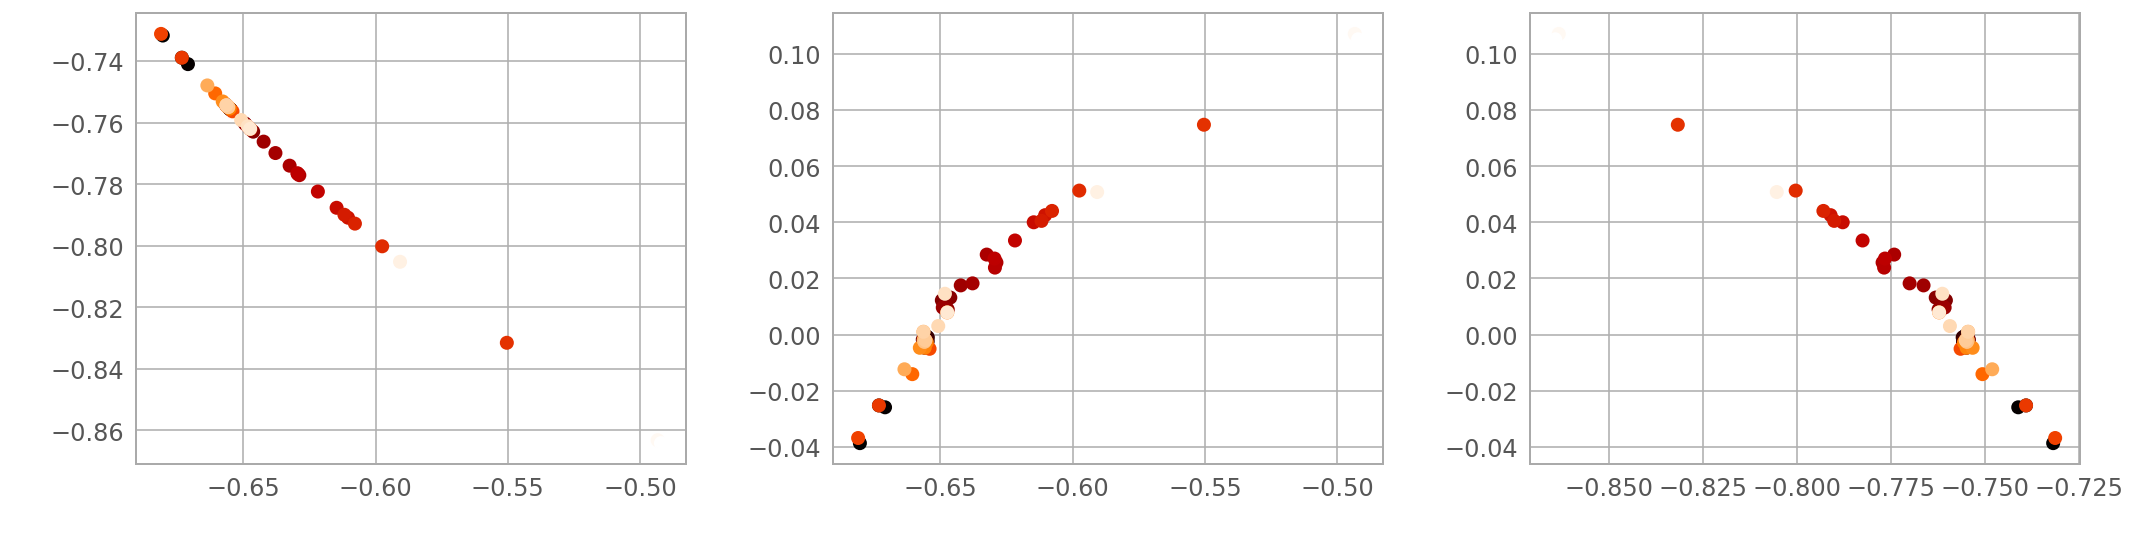

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(pal5_obs.x, pal5_obs.y, c=pal5_clr)
axs[1].scatter(pal5_obs.x, pal5_obs.z, c=pal5_clr)
axs[2].scatter(pal5_obs.y, pal5_obs.z, c=pal5_clr)
plt.tight_layout()
plt.show();

<br><br>

- - - 


## Preprocessing

### Orbit

  0%|          | 0/10 [00:00<?, ?it/s]

/Users/nathanielstarkman/miniconda3/envs/dev/lib/python3.8/site-packages/minisom.py:365: UserWarning: PCA initialization inappropriate:One of the dimensions of the map is 1.
  warn(msg)



100%|██████████| 10/10 [00:01<00:00,  5.19it/s]


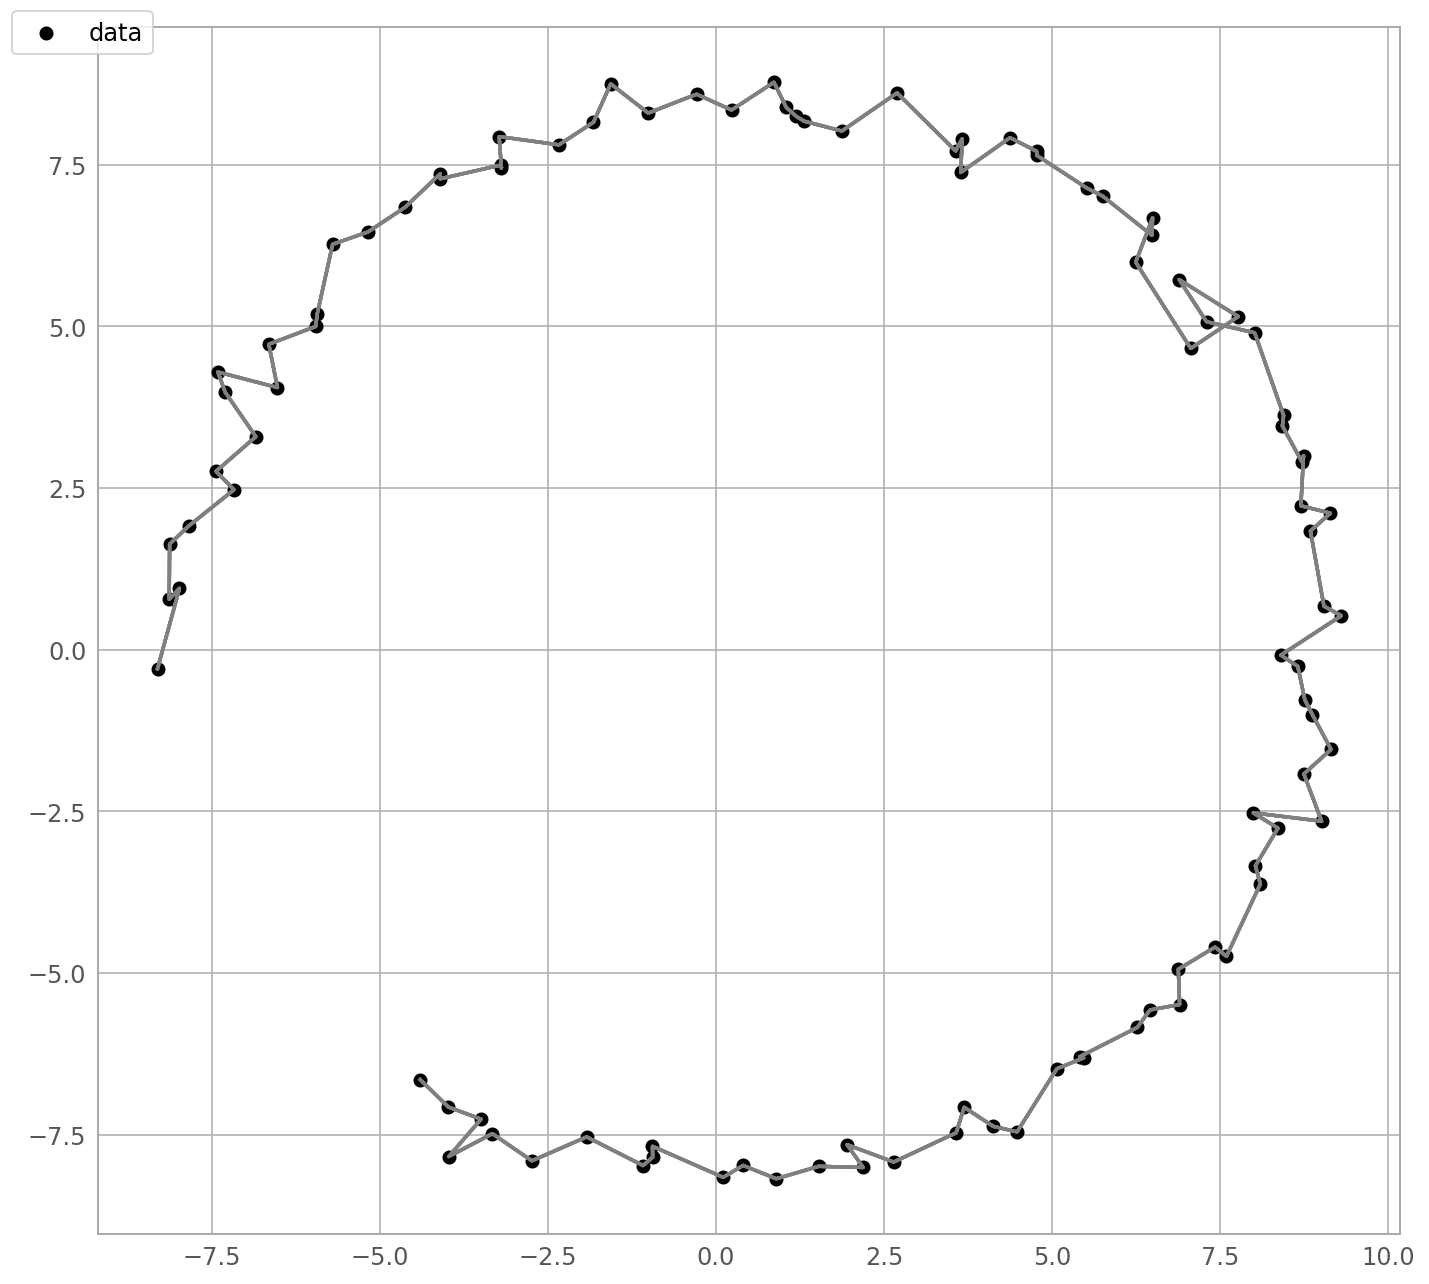

In [9]:
orb_repdata, orb_trmat, orb_visit_orders, orb_start_point = prep.preprocess(
    orb_obs,
    start_point=np.array((-5, -2, 0.0)),
    iterations=int(3e3),
    learning_rate=1.5,
    sigma=15,
    plot=True,
    random_seeds=np.arange(10, 20, 1),
    _tqdm=True,
)

### NBody

  0%|          | 0/10 [00:00<?, ?it/s]

/Users/nathanielstarkman/miniconda3/envs/dev/lib/python3.8/site-packages/minisom.py:365: UserWarning: PCA initialization inappropriate:One of the dimensions of the map is 1.
  warn(msg)



100%|██████████| 10/10 [00:03<00:00,  3.24it/s]


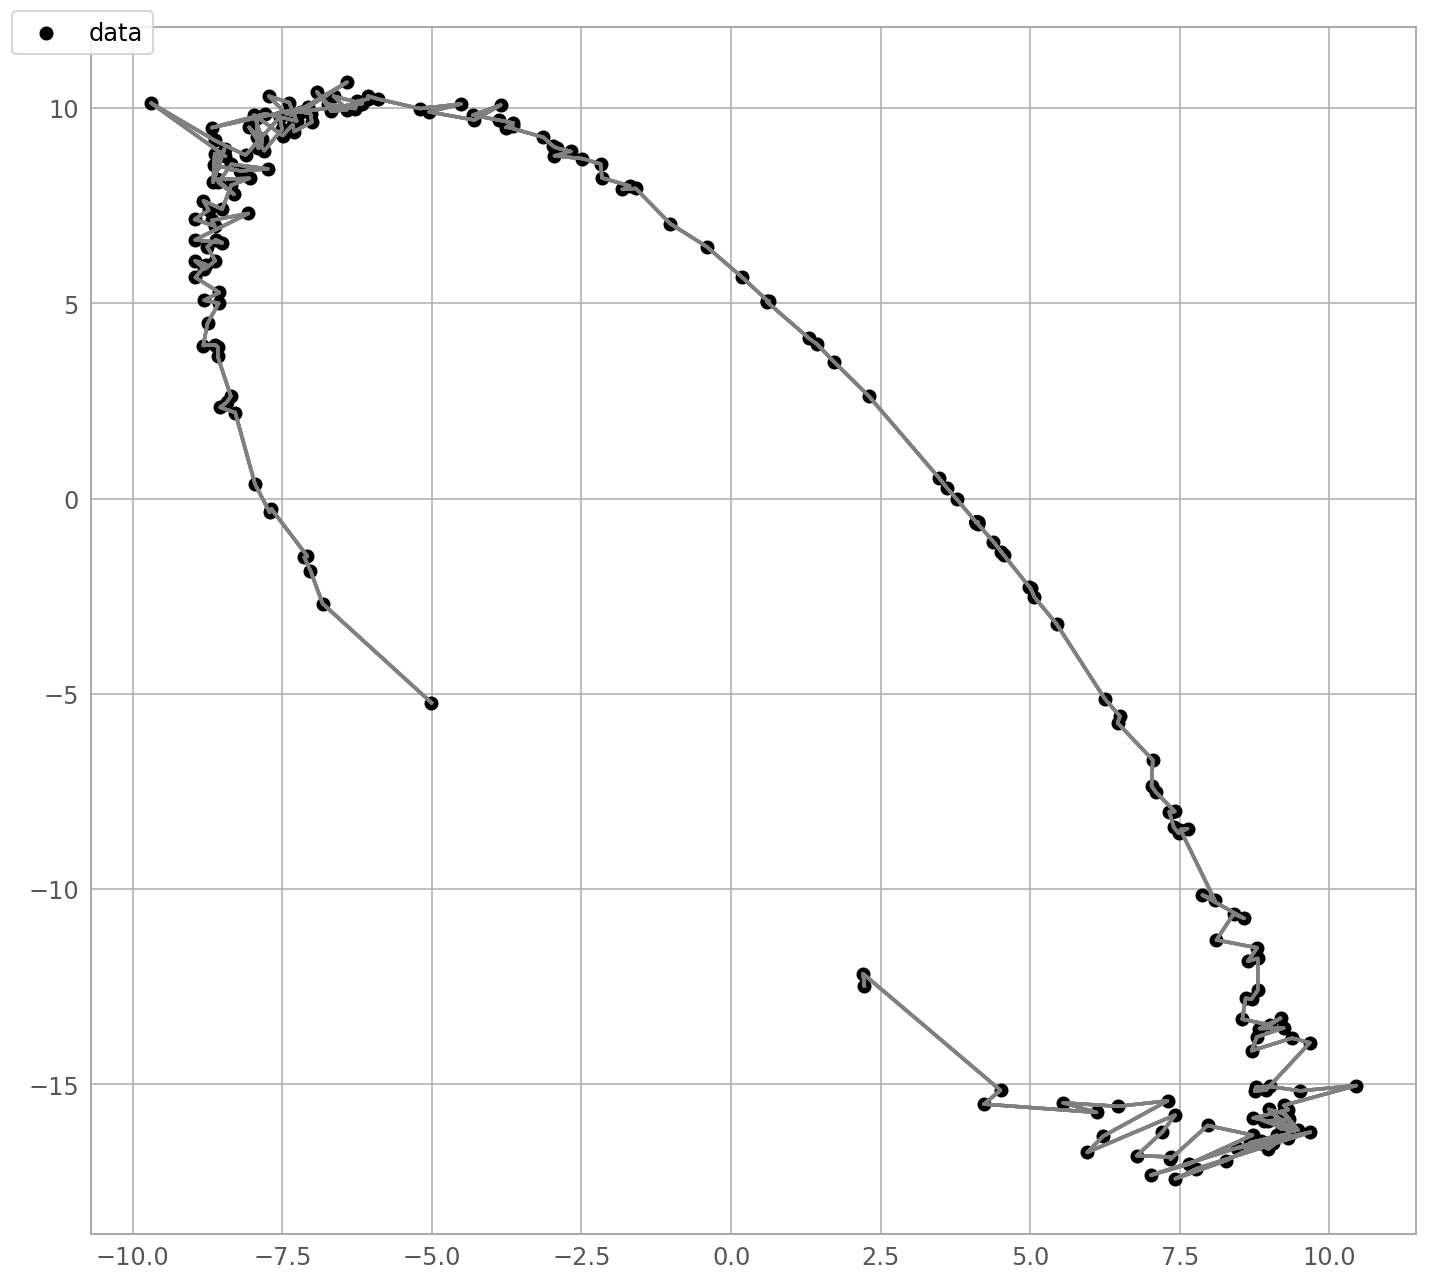

In [10]:
nbd_repdata, nbd_trmat, nbd_visit_orders, nbd_start_point = prep.preprocess(
    nbd_obs,
    start_point=np.array((-5, -5, 12.0)),
    iterations=int(3e3),
    learning_rate=2.,
    sigma=20,
    plot=True,
    random_seeds=np.arange(10, 20, 1),
    _tqdm=True,
)

### Obs

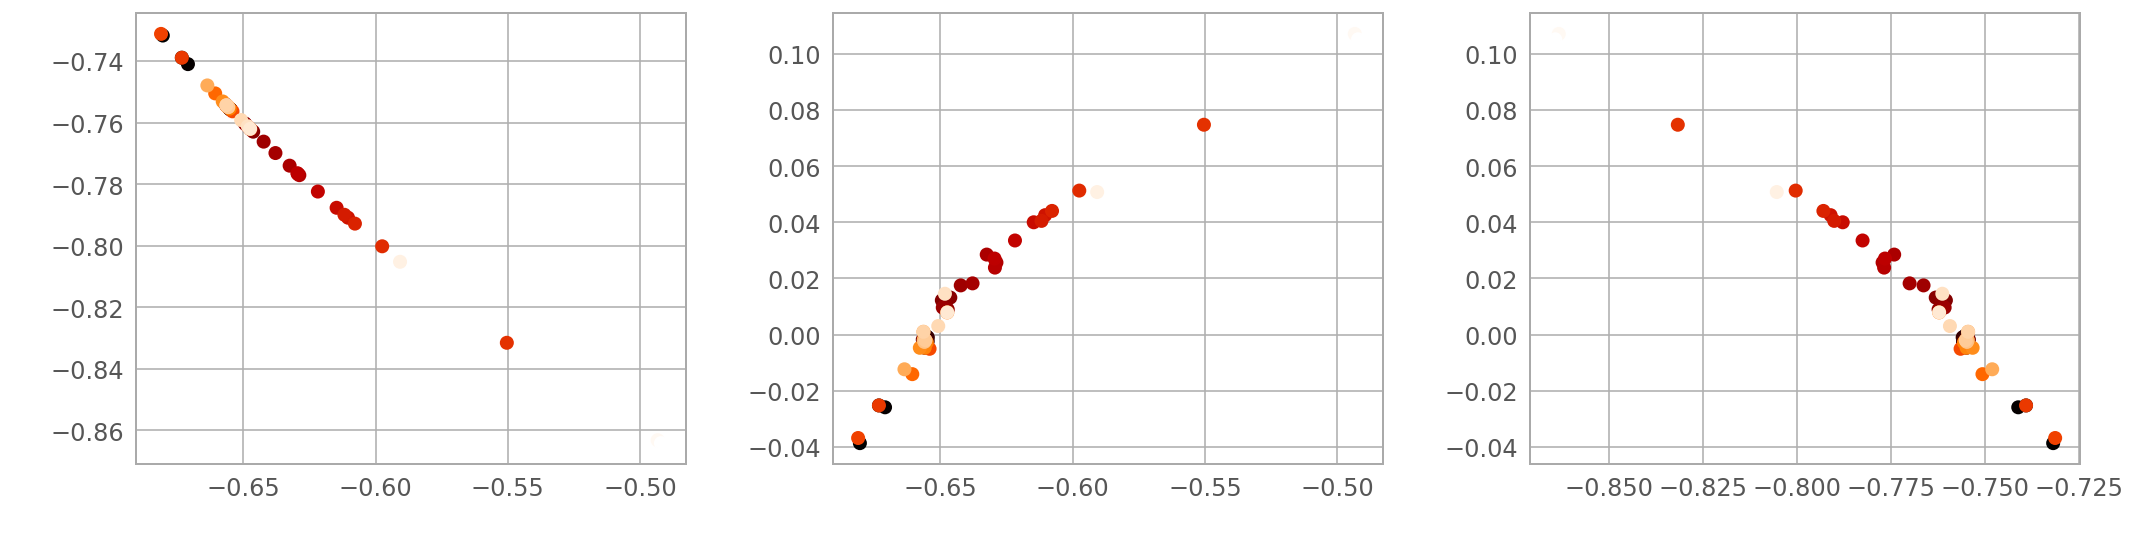

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(pal5_obs.x, pal5_obs.y, c=pal5_clr)
axs[1].scatter(pal5_obs.x, pal5_obs.z, c=pal5_clr)
axs[2].scatter(pal5_obs.y, pal5_obs.z, c=pal5_clr)
plt.tight_layout()
plt.show();

  0%|          | 0/10 [00:00<?, ?it/s]

/Users/nathanielstarkman/miniconda3/envs/dev/lib/python3.8/site-packages/minisom.py:365: UserWarning: PCA initialization inappropriate:One of the dimensions of the map is 1.
  warn(msg)



100%|██████████| 10/10 [00:01<00:00,  5.73it/s]


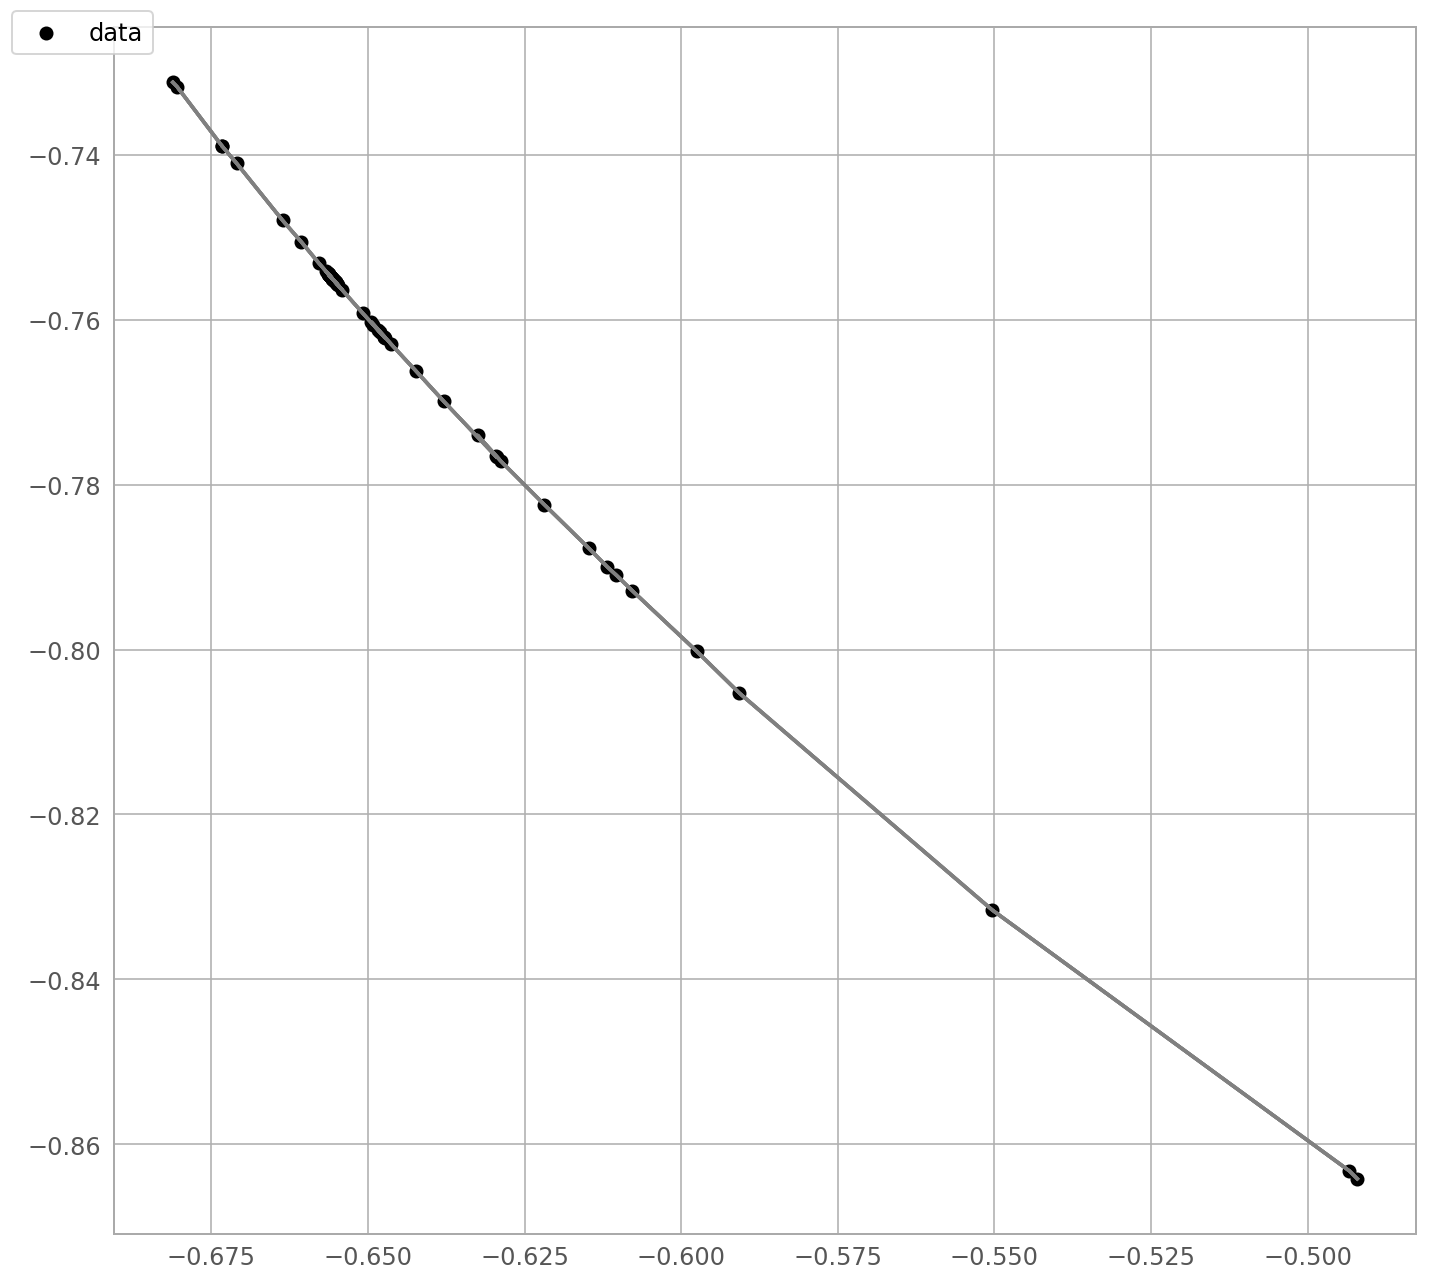

In [12]:
pal5_repdata, pal5_trmat, pal5_visit_orders, pal5_start_point = prep.preprocess(
    pal5_obs,
    start_point=np.array((-0.7, -0.72, -0.04)),
    iterations=int(3e3),
    learning_rate=2.,
    sigma=20,
    plot=True,
    random_seeds=np.arange(10, 20, 1),
    _tqdm=True,
)

<br><br>

- - - 


## g-h filter

### Orbit

In [13]:
orb_best_order = prep.draw_most_probable_ordering(orb_trmat)

ii = np.arange(len(orb_best_order))
orb_meas = orb_repdata[orb_best_order]

dx = np.array([1., 10, 0.25]) / 10

Running

In [14]:
orb_ghf_x = GHKFilter(x=orb_start_point[0], dx=dx[0], ddx=0, dt=0.5, g=0.4, h=0.1, k=0.006)
orb_res_x, orb_pred_x = orb_ghf_x.batch_filter(orb_meas.x, save_predictions=True)

orb_ghf_y = GHKFilter(x=orb_start_point[1], dx=dx[1], ddx=0, dt=0.5, g=0.4, h=0.1, k=0.006)
orb_res_y, orb_pred_y = orb_ghf_y.batch_filter(orb_meas.y, save_predictions=True)

orb_ghf_z = GHKFilter(x=orb_start_point[2], dx=dx[2], ddx=0, dt=0.5, g=0.4, h=0.1, k=0.006)
orb_res_z, orb_pred_z = orb_ghf_z.batch_filter(orb_meas.z, save_predictions=True)

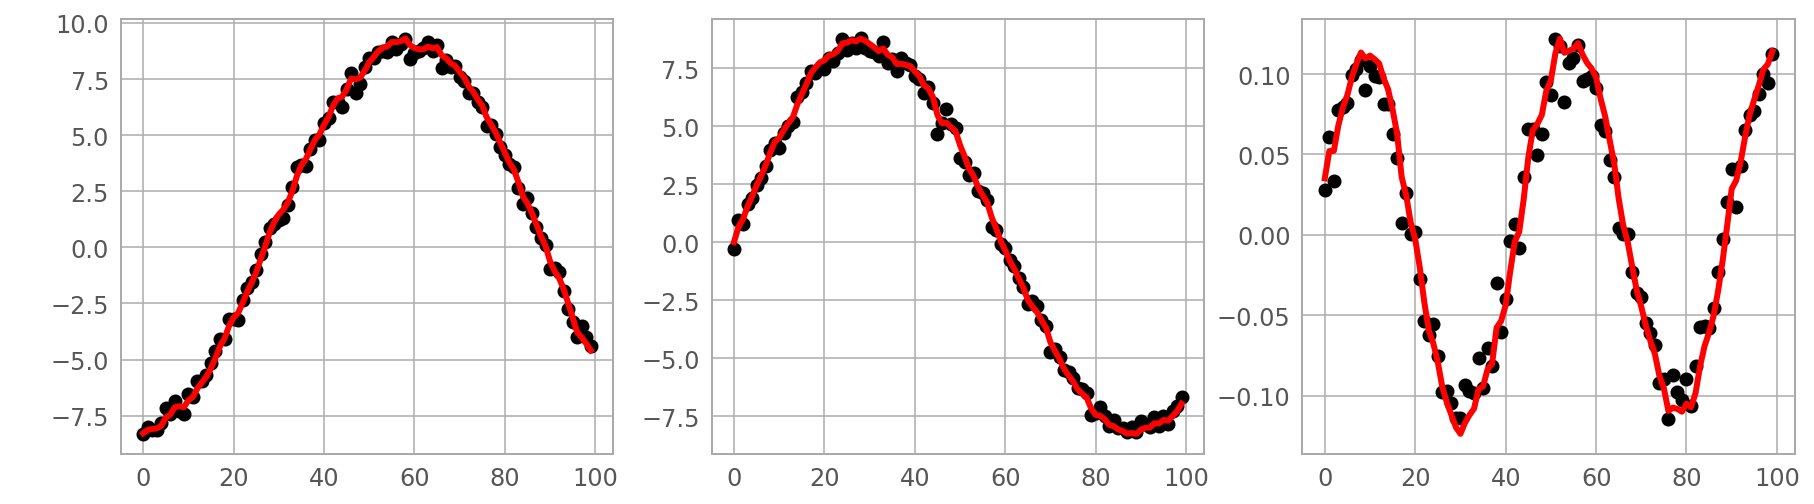

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(ii, orb_meas.x, c="k")
axs[0].plot(ii, orb_res_x[1:,0], c="red", lw=3)

axs[1].scatter(ii, orb_meas.y, c="k")
axs[1].plot(ii, orb_res_y[1:,0], c="red", lw=3)

axs[2].scatter(ii, orb_meas.z, c="k")
axs[2].plot(ii, orb_res_z[1:,0], c="red", lw=3)

plt.show();

### NBody

In [18]:
nbd_best_order = prep.draw_most_probable_ordering(nbd_trmat)

ii = np.arange(len(nbd_best_order))
nbd_meas = nbd_repdata[nbd_best_order]

dx = np.array([1., 10, 0.25]) / 10

Running

In [23]:
nbd_ghf_x = GHKFilter(x=nbd_start_point[0], dx=dx[0], ddx=0, dt=0.5, g=0.4, h=0.1, k=0.006)
nbd_res_x, nbd_pred_x = nbd_ghf_x.batch_filter(nbd_meas.x.value, save_predictions=True)

nbd_ghf_y = GHKFilter(x=nbd_start_point[1], dx=dx[1], ddx=0, dt=0.5, g=0.4, h=0.1, k=0.006)
nbd_res_y, nbd_pred_y = nbd_ghf_y.batch_filter(nbd_meas.y.value, save_predictions=True)

nbd_ghf_z = GHKFilter(x=nbd_start_point[2], dx=dx[2], ddx=0, dt=0.5, g=0.4, h=0.1, k=0.006)
nbd_res_z, nbd_pred_z = nbd_ghf_z.batch_filter(nbd_meas.z.value, save_predictions=True)

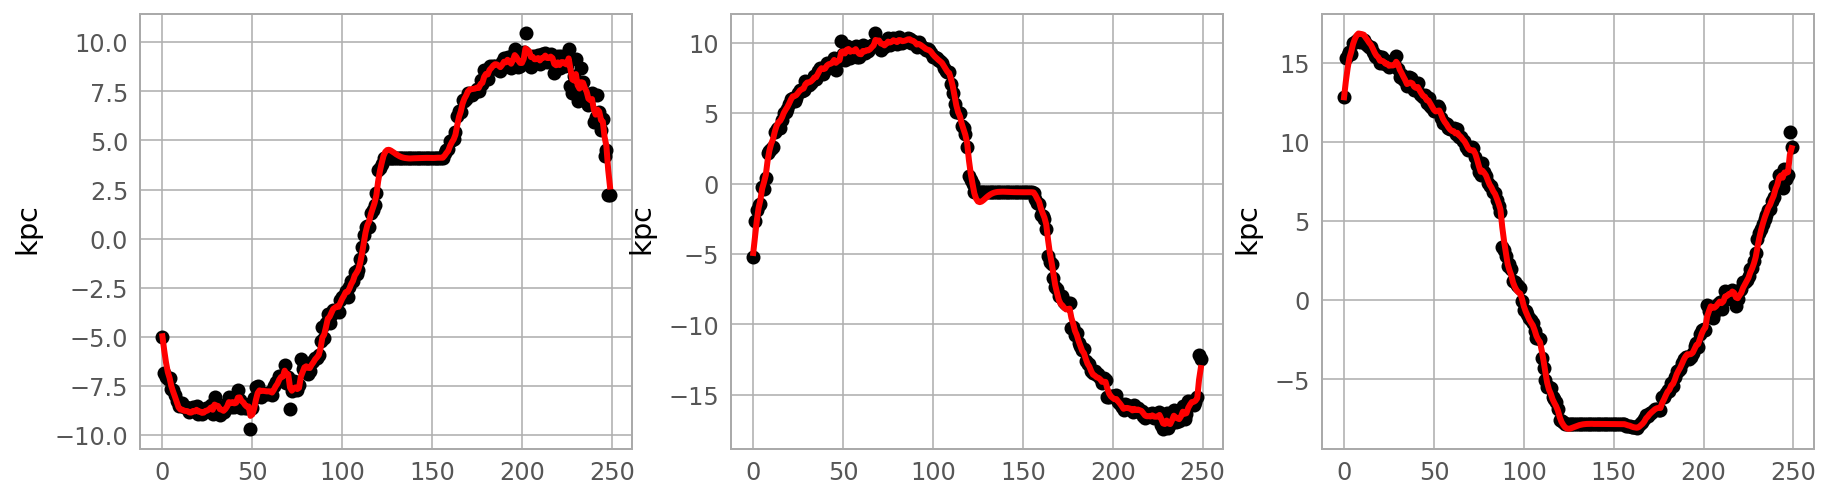

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(ii, nbd_meas.x, c="k")
axs[0].plot(ii, nbd_res_x[1:,0], c="red", lw=3)

axs[1].scatter(ii, nbd_meas.y, c="k")
axs[1].plot(ii, nbd_res_y[1:,0], c="red", lw=3)

axs[2].scatter(ii, nbd_meas.z, c="k")
axs[2].plot(ii, nbd_res_z[1:,0], c="red", lw=3)

plt.show();

### Obs

In [37]:
pal5_best_order = prep.draw_most_probable_ordering(pal5_trmat)

ii = np.arange(len(pal5_best_order))
pal5_meas = pal5_repdata[?               
                          ,l. pal5_best_order]

dx = np.array([0, 0, 0.]) / 10

Running

In [38]:
pal5_ghf_x = GHKFilter(x=pal5_start_point[0], dx=dx[0], ddx=0, dt=0.5, g=0.4, h=0.1, k=0.006)
pal5_res_x, pal5_pred_x = pal5_ghf_x.batch_filter(pal5_meas.x.value, save_predictions=True)

pal5_ghf_y = GHKFilter(x=pal5_start_point[1], dx=dx[1], ddx=0, dt=0.5, g=0.4, h=0.1, k=0.006)
pal5_res_y, pal5_pred_y = pal5_ghf_y.batch_filter(pal5_meas.y.value, save_predictions=True)

pal5_ghf_z = GHKFilter(x=pal5_start_point[2], dx=dx[2], ddx=0, dt=0.5, g=0.4, h=0.1, k=0.006)
pal5_res_z, pal5_pred_z = pal5_ghf_z.batch_filter(pal5_meas.z.value, save_predictions=True)

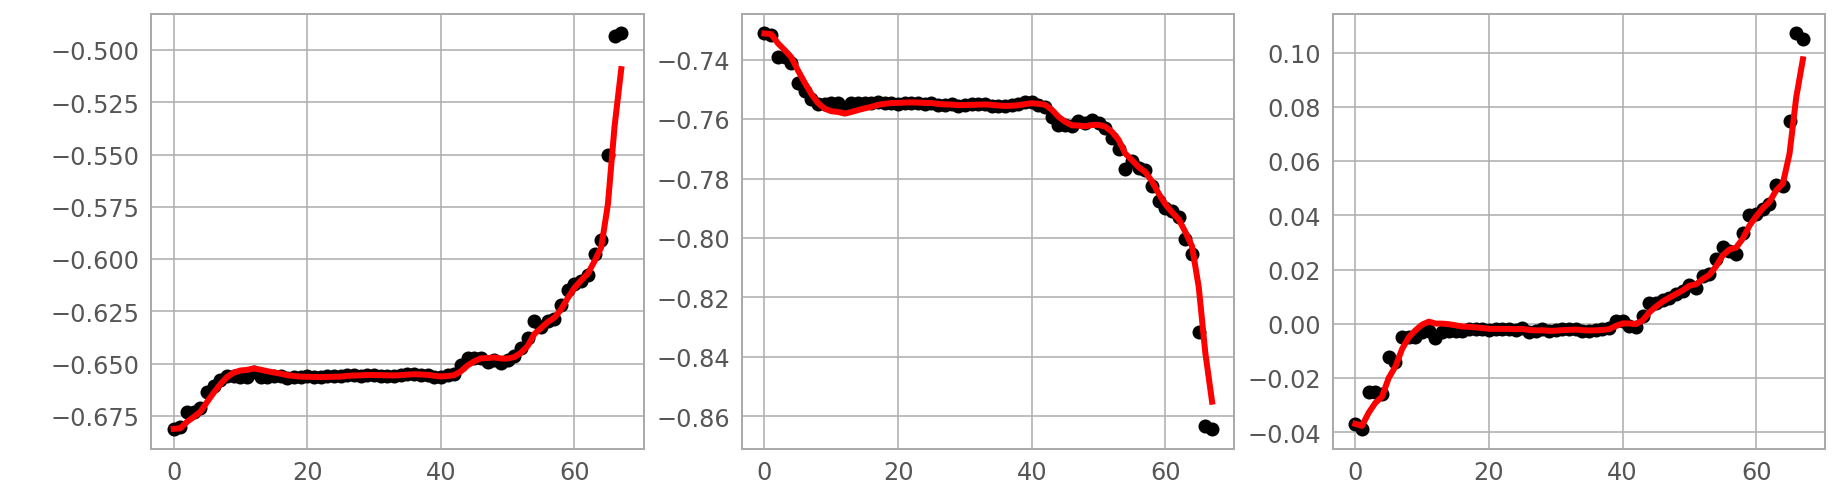

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(ii, pal5_meas.x, c="k")
axs[0].plot(ii, pal5_res_x[1:,0], c="red", lw=3)

axs[1].scatter(ii, pal5_meas.y, c="k")
axs[1].plot(ii, pal5_res_y[1:,0], c="red", lw=3)

axs[2].scatter(ii, pal5_meas.z, c="k")
axs[2].plot(ii, pal5_res_z[1:,0], c="red", lw=3)

plt.show();

<br><br>

- - - 

<span style='font-size:40px;font-weight:650'>
    END
</span>